**Why not Linear regrssion**

 *Lets take a classification examples where we try to classify a person as a obese or not given the weight*

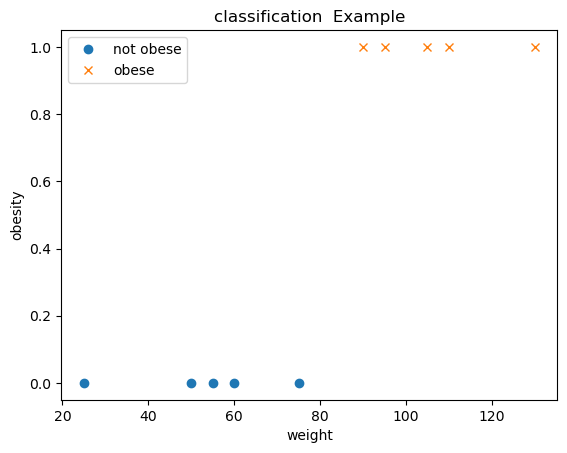

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# data point for class '0' (not obese)
x0=[25,50,55,60,75]
y0=[0,0,0,0,0]

# data point for class '1' (obese)
x1=[90,95,105,110,130]
y1=[1,1,1,1,1]

# now plot the data points 
plt.plot(x0,y0, marker='o',linestyle='', label='not obese')
plt.plot(x1,y1, marker='x',linestyle='',label='obese')

#set plot labels and title 
plt.ylabel('obesity')
plt.xlabel('weight')
plt.title('classification  Example')


# add legend 
plt.legend()

#show the plot
plt.show()





**Now we try to understand why we need Logistic regression and why linear regression fails**

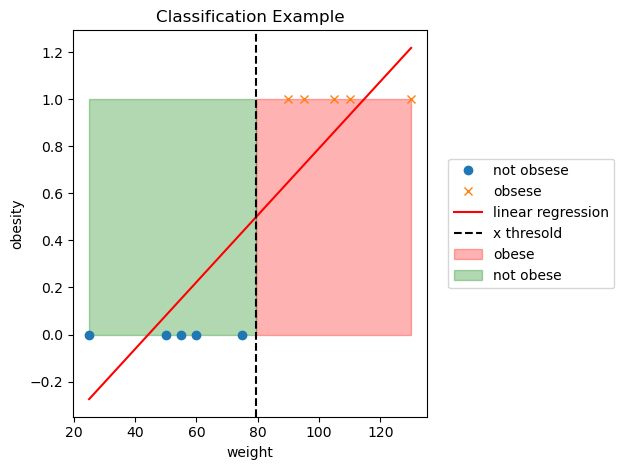

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# define the data point 
x0=[25,50,55,60,75]
y0=[0,0,0,0,0]

x1=[90,95,105,110,130]
y1=[1,1,1,1,1]

# combine the data points 
x=np.concatenate([x0,x1]).reshape(-1,1)
y=np.concatenate([y0,y1])

# fit a linear regrssion model 
model=LinearRegression()
model.fit(x,y)

# generate prediction using the linear regression model 
x_pred=np.linspace(min(x),max(x),100).reshape(-1,1)
y_pred=model.predict(x_pred)

# plot the data points 
plt.plot(x0,y0, marker='o',linestyle='',label='not obsese')
plt.plot(x1,y1, marker='x',linestyle='',label='obsese')

# plot the linear regression line
plt.plot(x_pred,y_pred,color='r',label="linear regression")

#  find the x- value corresponding to y=0.5 
x_threshold= (0.5-model.intercept_)/model.coef_

# add a verticle line at the x-value corresponding to y=0.5
plt.axvline(x=x_threshold[0],color='k',linestyle='--', label="x thresold",)

# fill the region on each side of the threshold  line

# Fill the regions on each side of the threshold line
plt.fill_betweenx([0, 1], x_threshold[0], max(x_pred), color='red', alpha=0.3, label='obese')
plt.fill_betweenx([0, 1], min(x_pred), x_threshold[0], color='green', alpha=0.3, label='not obese')

# set plot label and title 
plt.ylabel('obesity')
plt.xlabel('weight')
plt.title('Classification Example')


# move the legend outside the plot 
plt.legend(bbox_to_anchor=(1.04,0.5),loc='center left')

# adjust the plot layout 
plt.tight_layout()

#show the plot
plt.show()



now we apply logistic regression on this and fit a sigmoid curve through the data point 

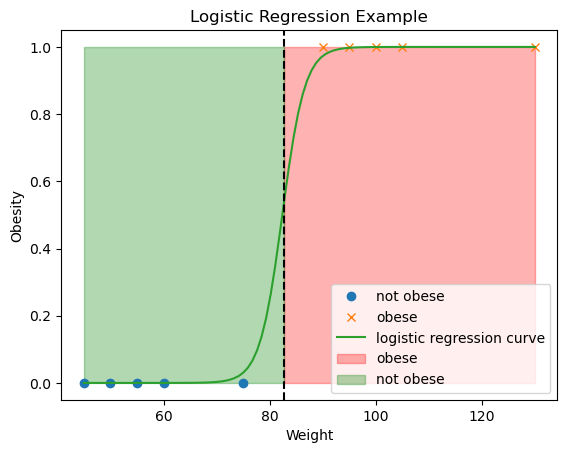

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Define the data points
x0 = [45, 50, 55, 60,75]
y0 = [0, 0, 0, 0,0]

x1 = [90, 95, 100, 105,130]
y1 = [1, 1, 1, 1,1]


# Define the input data
x = np.array(x0 + x1).reshape(-1, 1)
y = np.array(y0 + y1) 

#create an instance of the logistic regression model 
model=LogisticRegression()

#fit the model to the data
model.fit(x,y)


# Generate the curve points for plotting
x_curve = np.linspace(min(x), max(x), 100).reshape(-1, 1)
y_curve = model.predict_proba(x_curve)[:, 1]

# Plot the data points
plt.plot(x0, y0, marker='o', linestyle='', label='not obese')
plt.plot(x1, y1, marker='x', linestyle='', label='obese')

# Plot the logistic regression curve
plt.plot(x_curve, y_curve, label='logistic regression curve')

# Set plot labels and title
plt.ylabel('Obesity')
plt.xlabel('Weight')
plt.title('Logistic Regression Example')

# Find the x value corresponding to y=0.5(threshold)
x_threshold = x_curve[np.where(np.abs(y_curve - 0.5) == np.min(np.abs(y_curve - 0.5)))][0]

# Draw the vertical line
plt.axvline(x=x_threshold, color='black', linestyle='--')

# Fill the regions on each side of the threshold line
plt.fill_betweenx([0, 1], x_threshold[0], max(x_curve), color='red', alpha=0.3, label='obese')
plt.fill_betweenx([0, 1], min(x_curve), x_threshold[0], color='green', alpha=0.3, label='not obese')

# Add legend
plt.legend()

# Show the plot
plt.show()
  



In [ ]:
# now we can see that the logistic regression curve is a sigmoid function that smoothly transitions from 0 to 1 as the weight increases.
#  The vertical dashed line represents the threshold where the predicted probability of being obese is 0.5. The shaded regions indicate the areas where the model predicts 'not obese' (green) and 'obese' (red). 
# This visualization helps us understand how the logistic regression model classifies data points based on their weight.
# weight is the feature and obesity is the target variable. The logistic regression model learns to predict the probability of being obese based on weight, and the curve illustrates how this probability changes as weight increases.

# Cost Function

C:\Users\HP\AppData\Local\Temp\ipykernel_37856\3776446423.py:32: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  J[i, j] = squared_error_cost_linear(M[i, j], B[i, j], x_train, y_train)
C:\Users\HP\AppData\Local\Temp\ipykernel_37856\3776446423.py:50: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  J[i, j] = squared_error_cost_logistic(W[i, j], B[i, j], x_train, y_train)


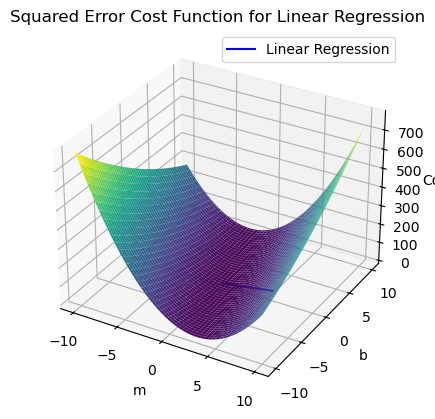

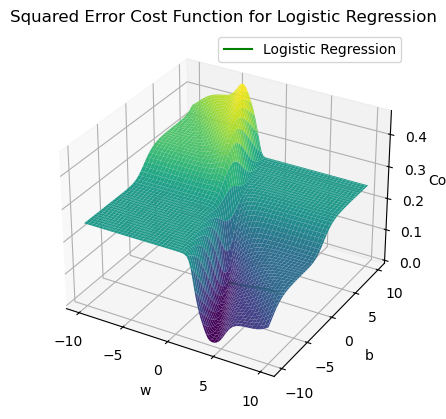

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression

def squared_error_cost_linear(m, b, x, y):
    n = len(x)
    cost = 0.0
    for i in range(n):
        y_pred = m * x[i] + b
        cost += (y_pred - y[i]) ** 2
    cost /= (2 * n)
    return cost

def squared_error_cost_logistic(w, b, x, y):
    m = len(x)
    cost = 0.0
    for i in range(m):
        z = w * x[i] + b
        y_pred = 1 / (1 + np.exp(-z))
        cost += (y_pred - y[i]) ** 2
    cost /= (2 * m)
    return cost

def plot_squared_error_cost_linear(x_train, y_train):
    m_range = np.linspace(-10, 10, 100)
    b_range = np.linspace(-10, 10, 100)
    M, B = np.meshgrid(m_range, b_range)
    J = np.zeros_like(M)

    for i in range(len(m_range)):
        for j in range(len(b_range)):
            J[i, j] = squared_error_cost_linear(M[i, j], B[i, j], x_train, y_train)

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(M, B, J, cmap='viridis')
    ax.set_xlabel('m')
    ax.set_ylabel('b')
    ax.set_zlabel('Cost')
    ax.set_title('Squared Error Cost Function for Linear Regression')

def plot_squared_error_cost_logistic(x_train, y_train):
    w_range = np.linspace(-10, 10, 100)
    b_range = np.linspace(-10, 10, 100)
    W, B = np.meshgrid(w_range, b_range)
    J = np.zeros_like(W)

    for i in range(len(w_range)):
        for j in range(len(b_range)):
            J[i, j] = squared_error_cost_logistic(W[i, j], B[i, j], x_train, y_train)

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(W, B, J, cmap='viridis')
    ax.set_xlabel('w')
    ax.set_ylabel('b')
    ax.set_zlabel('Cost')
    ax.set_title('Squared Error Cost Function for Logistic Regression')

# Sample data
x_train = np.array([0, 1, 2, 3, 4, 5], dtype=np.longdouble).reshape(-1, 1)
y_train = np.array([0, 0, 0, 1, 1, 1], dtype=np.longdouble)

# Linear Regression using scikit-learn
linear_reg = LinearRegression()
linear_reg.fit(x_train, y_train)

# Logistic Regression using scikit-learn
logistic_reg = LogisticRegression()
logistic_reg.fit(x_train, y_train)

# Plotting the results
plot_squared_error_cost_linear(x_train, y_train)

plt.plot(x_train, linear_reg.predict(x_train), color='blue', label='Linear Regression')
plt.legend()

plot_squared_error_cost_logistic(x_train, y_train)

plt.plot(x_train, logistic_reg.predict_proba(x_train)[:, 1], color='green', label='Logistic Regression')
plt.legend()

plt.show()
